# Chapter 3: Time Value of Money and Investment Decisions

This chapter converts the lecture formulas into reusable Python modules. Every
code cell is self-contained and uses either a formula, `numpy-financial`, or
both to verify the result.

## Learning map

1. Cash-flow timelines and rate consistency
2. Future and present value
3. Perpetuities and delayed perpetuities
4. Ordinary annuities and annuities due
5. Growing annuities
6. Excel and `numpy-financial` sign conventions
7. NPV and IRR decision rules
8. Ordinary and discounted payback periods
9. NPV profiles and multiple IRRs

**Code availability:** Yes. Every code cell imports its own dependencies and
produces a numerical or visual result.

## How to Study This Chapter

- Draw a cash-flow timeline before selecting a formula.
- Label the rate frequency and payment timing explicitly.
- Compare manual formulas with `numpy-financial` outputs.
- Practice both valuation questions and accept/reject decision rules.

## Exam Checklist

- Can I distinguish ordinary, due, growing, and delayed cash-flow patterns?
- Can I apply the Excel sign convention correctly?
- Can I calculate and interpret NPV, IRR, and payback?
- Can I explain why non-conventional cash flows may generate multiple IRRs?


## 3.1 Cash-Flow Timelines and Rate Consistency

A timeline identifies **when** each cash flow occurs. Receiving money is
normally represented as positive, while investing or repaying money is
negative. The period rate and number of periods must have the same frequency.

Example loan timeline:

| Time | Borrower's cash flow |
|---:|---:|
| 0 | +100 |
| 1 | -10 |
| 2 | -110 |


## 3.2 Future Value and Present Value


The core formulas are:

$$FV=PV(1+r)^n, \qquad PV=\frac{FV}{(1+r)^n}$$

These functions form the basis of bond, stock, project, and derivative
valuation.



### Structured Review

- **Inputs:** Identify the cash-flow amount, timing, period rate, and number of periods.
- **Timeline first:** Mark time 0 separately and determine whether payments occur at the beginning or end of each period.
- **Frequency check:** Convert the rate or period count whenever their frequencies do not match.
- **Decision link:** Separate a valuation result from a project decision rule.

### Exam Focus

- Be able to reconstruct the formula from the cash-flow timeline.
- Check the exponent, discounting direction, and cash-flow sign.
- Verify a library result with a short manual calculation whenever possible.

### Common Mistakes

- Mixing annual rates with monthly periods.
- Discounting the time-zero cash flow.
- Confusing an annuity due with an ordinary annuity.


In [1]:
'''
本单元同时定义终值和现值函数，并进行双向验证。
r 为每期利率，n 为期数，两者的频率必须一致。
'''
def future_value(pv, r, n):
    # 终值：把当前金额按每期利率复利 n 期
    return pv * (1 + r) ** n

def present_value(fv, r, n):
    # 现值：把未来金额除以复利因子
    return fv / (1 + r) ** n

fv = future_value(pv=100, r=0.0123, n=5)
pv = present_value(fv=100, r=0.05, n=5)

print("FV example =", round(fv, 2))
print("PV example =", round(pv, 2))
print("Reverse-check =", round(present_value(fv, 0.0123, 5), 2))


FV example = 106.3
PV example = 78.35
Reverse-check = 100.0


**Result interpretation.** The lecture future-value example is about $106.30, and discounting $100 for five years at 5% gives about $78.35.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 3.3 Perpetuities and Delayed Perpetuities


An ordinary perpetuity pays the same cash flow forever, beginning one period
from today:

$$PV_0=\frac{C}{r}$$

If the first payment arrives at time `k`, first value the perpetuity at time
`k-1`, then discount it back to time zero:

$$PV_0=\frac{C/r}{(1+r)^{k-1}}$$



### Structured Review

- **Inputs:** Identify the cash-flow amount, timing, period rate, and number of periods.
- **Timeline first:** Mark time 0 separately and determine whether payments occur at the beginning or end of each period.
- **Frequency check:** Convert the rate or period count whenever their frequencies do not match.
- **Decision link:** Separate a valuation result from a project decision rule.

### Exam Focus

- Be able to reconstruct the formula from the cash-flow timeline.
- Check the exponent, discounting direction, and cash-flow sign.
- Verify a library result with a short manual calculation whenever possible.

### Common Mistakes

- Mixing annual rates with monthly periods.
- Discounting the time-zero cash flow.
- Confusing an annuity due with an ordinary annuity.


In [2]:
'''
本单元计算普通永续年金与延期永续年金。
k 表示第一笔现金流发生的期数，因此永续年金价值位于 k-1 期。
'''
def pv_perpetuity(cash_flow, rate):
    # 普通永续年金第一笔现金流发生在第 1 期末
    return cash_flow / rate

def pv_delayed_perpetuity(cash_flow, rate, first_payment_period):
    # 永续年金价值位于第一笔付款的前一期，即 k-1 期
    value_before_first_payment = cash_flow / rate

    # 再将 k-1 期的价值折现回 0 期
    return value_before_first_payment / (1 + rate) ** (first_payment_period - 1)

ordinary = pv_perpetuity(cash_flow=100, rate=0.10)
delayed = pv_delayed_perpetuity(cash_flow=100, rate=0.10, first_payment_period=4)

print("Ordinary perpetuity PV =", round(ordinary, 2))
print("Delayed perpetuity PV =", round(delayed, 2))


Ordinary perpetuity PV = 1000.0
Delayed perpetuity PV = 751.31


**Result interpretation.** The ordinary perpetuity is worth $1,000 today; delaying its first payment to year 4 lowers today's value.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 3.4 Ordinary Annuities and Annuities Due


An ordinary annuity pays at each period end:

$$PV=C\frac{1-(1+r)^{-n}}{r}, \qquad
FV=C\frac{(1+r)^n-1}{r}$$

An annuity due pays at each period beginning, so its value equals the ordinary
annuity value multiplied by `(1+r)`.



### Structured Review

- **Inputs:** Identify the cash-flow amount, timing, period rate, and number of periods.
- **Timeline first:** Mark time 0 separately and determine whether payments occur at the beginning or end of each period.
- **Frequency check:** Convert the rate or period count whenever their frequencies do not match.
- **Decision link:** Separate a valuation result from a project decision rule.

### Exam Focus

- Be able to reconstruct the formula from the cash-flow timeline.
- Check the exponent, discounting direction, and cash-flow sign.
- Verify a library result with a short manual calculation whenever possible.

### Common Mistakes

- Mixing annual rates with monthly periods.
- Discounting the time-zero cash flow.
- Confusing an annuity due with an ordinary annuity.


In [3]:
'''
本单元计算普通年金及先付年金的现值和终值。
先付年金比普通年金早一期收到每笔现金流，因此多乘一个增长因子。
'''
def pv_annuity(cash_flow, rate, periods, due=False):
    # 先计算期末支付的普通年金现值
    value = cash_flow * (1 - (1 + rate) ** (-periods)) / rate

    # 先付年金每笔现金流提前一期，因此普通年金价值乘以 (1+r)
    return value * (1 + rate) if due else value

def fv_annuity(cash_flow, rate, periods, due=False):
    # 普通年金终值公式
    value = cash_flow * ((1 + rate) ** periods - 1) / rate

    # due=True 时转换为先付年金终值
    return value * (1 + rate) if due else value

pv_ordinary = pv_annuity(100, 0.05, 10)
pv_due = pv_annuity(100, 0.05, 10, due=True)
fv_ordinary = fv_annuity(100, 0.05, 10)

print("Ordinary annuity PV =", round(pv_ordinary, 2))
print("Annuity-due PV =", round(pv_due, 2))
print("Ordinary annuity FV =", round(fv_ordinary, 2))


Ordinary annuity PV = 772.17
Annuity-due PV = 810.78
Ordinary annuity FV = 1257.79


**Result interpretation.** Earlier payments make the annuity due more valuable than the otherwise identical ordinary annuity.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 3.5 Growing Annuities


For a first payment `C` at time 1 growing at rate `g`, the present value is:

$$PV=C\frac{1-\left(\frac{1+g}{1+r}\right)^n}{r-g}, \quad r\ne g$$

The future value at time `n` is:

$$FV=C\frac{(1+r)^n-(1+g)^n}{r-g}$$

**Correction to the raw course script:** the denominator must be `r-g`, not
`r`. The corrected formula below is also verified by discounting each cash flow.



### Structured Review

- **Inputs:** Identify the cash-flow amount, timing, period rate, and number of periods.
- **Timeline first:** Mark time 0 separately and determine whether payments occur at the beginning or end of each period.
- **Frequency check:** Convert the rate or period count whenever their frequencies do not match.
- **Decision link:** Separate a valuation result from a project decision rule.

### Exam Focus

- Be able to reconstruct the formula from the cash-flow timeline.
- Check the exponent, discounting direction, and cash-flow sign.
- Verify a library result with a short manual calculation whenever possible.

### Common Mistakes

- Mixing annual rates with monthly periods.
- Discounting the time-zero cash flow.
- Confusing an annuity due with an ordinary annuity.


In [4]:
'''
本单元实现增长年金的正确公式，并用逐期现金流求和进行验证。
原始课程总代码分母写成 r；标准公式分母应为 r-g。
当 r 与 g 相等时，改用逐期求和以避免除零。
'''
def pv_growing_annuity(cash_flow, rate, growth, periods):
    # r=g 时标准公式分母为零，必须改用逐期折现求和
    if abs(rate - growth) < 1e-12:
        return sum(
            cash_flow * (1 + growth) ** (t - 1) / (1 + rate) ** t
            for t in range(1, periods + 1)
        )

    # 重要填空：增长年金公式的分母是 rate-growth，不是 rate
    return cash_flow * (1 - ((1 + growth) / (1 + rate)) ** periods) / (rate - growth)

def fv_growing_annuity(cash_flow, rate, growth, periods):
    # r=g 时使用对应的极限形式
    if abs(rate - growth) < 1e-12:
        return cash_flow * periods * (1 + rate) ** (periods - 1)

    # 增长年金终值同样使用 rate-growth 作为分母
    return cash_flow * ((1 + rate) ** periods - (1 + growth) ** periods) / (rate - growth)

c, r, g, n = 100, 0.15, 0.02, 10
formula_pv = pv_growing_annuity(c, r, g, n)

# 逐期生成增长现金流并折现，用于检查封闭公式
direct_pv = sum(c * (1 + g) ** (t - 1) / (1 + r) ** t for t in range(1, n + 1))

print("Growing annuity PV =", round(formula_pv, 2))
print("Direct cash-flow check =", round(direct_pv, 2))
print("Growing annuity FV =", round(fv_growing_annuity(c, r, g, n), 2))


Growing annuity PV = 537.45
Direct cash-flow check = 537.45
Growing annuity FV = 2174.28


**Result interpretation.** The formula and direct cash-flow calculation match, confirming the corrected implementation.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 3.6 Excel and numpy-financial Sign Conventions


Excel-style financial functions treat cash inflows and outflows as opposite
signs. A positive future receipt therefore corresponds to a negative present
investment. `numpy-financial` follows this convention and mirrors functions
such as `PV`, `FV`, `PMT`, `NPER`, and `RATE`.



### Structured Review

- **Namespace:** Determine whether the function is called through a module name, an alias, or a direct import.
- **Dependency:** Import only the package required by the current code block.
- **Inspection:** Use version metadata, `dir()`, and documentation to understand an unfamiliar package.
- **Numerical object:** Distinguish ordinary Python containers from vectorized NumPy arrays.

### Exam Focus

- Complete the correct import statement before using a function.
- Recognize standard aliases such as `np`, `pd`, `yf`, and `plt`.
- Explain why wildcard imports make code harder to audit.

### Common Mistakes

- Installing a package into a different Python environment.
- Calling a module function without its namespace.
- Assuming a list automatically supports NumPy-style vectorized arithmetic.


In [5]:
'''
本单元展示 numpy_financial 的现金流符号约定。
今天支付 100 属于现金流出，因此输入 pv=-100，未来收到的金额为正。
'''
import numpy_financial as npf

# 现金流出使用负号：今天投入 100，未来收到正的终值
future_receipt = npf.fv(rate=0.10, nper=1, pmt=0, pv=-100)

# 未来收到 110 为正，因此对应的当前投入由函数返回负值
present_outflow = npf.pv(rate=0.10, nper=1, pmt=0, fv=110)

print("Future receipt =", round(float(future_receipt), 2))
print("Present outflow =", round(float(present_outflow), 2))


Future receipt = 110.0
Present outflow = -100.0


**Result interpretation.** The future receipt is positive and the corresponding present investment is negative, matching the Excel convention.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 3.7 Net Present Value and the NPV Rule


NPV discounts all project cash flows to time zero:

$$NPV=\sum_{t=0}^{n}\frac{CF_t}{(1+r)^t}$$

Decision rule: accept an independent project when `NPV > 0` and reject it when
`NPV < 0`. In `numpy_financial.npv`, include the time-zero cash flow as the first
element if using the full cash-flow list.



### Structured Review

- **Inputs:** Identify the cash-flow amount, timing, period rate, and number of periods.
- **Timeline first:** Mark time 0 separately and determine whether payments occur at the beginning or end of each period.
- **Frequency check:** Convert the rate or period count whenever their frequencies do not match.
- **Decision link:** Separate a valuation result from a project decision rule.

### Exam Focus

- Be able to reconstruct the formula from the cash-flow timeline.
- Check the exponent, discounting direction, and cash-flow sign.
- Verify a library result with a short manual calculation whenever possible.

### Common Mistakes

- Mixing annual rates with monthly periods.
- Discounting the time-zero cash flow.
- Confusing an annuity due with an ordinary annuity.


In [6]:
'''
本单元用手工公式和 numpy_financial 两种方法计算 NPV。
现金流列表的第一个元素是 0 期初始投资，负号表示现金流出。
'''
import numpy_financial as npf

cash_flows = [-100, 50, 60, 70]
required_return = 0.12

# enumerate 同时提供时间 t 和现金流 cf；0 期现金流不折现
manual_npv = sum(cf / (1 + required_return) ** t for t, cf in enumerate(cash_flows))

# npf.npv 将列表第一项视为 0 期现金流
library_npv = npf.npv(required_return, cash_flows)

# NPV 决策规则：大于 0 接受，否则拒绝
decision = "Accept" if library_npv > 0 else "Reject"

print("Manual NPV =", round(manual_npv, 2))
print("numpy-financial NPV =", round(float(library_npv), 2))
print("Decision =", decision)


Manual NPV = 42.3
numpy-financial NPV = 42.3
Decision = Accept


**Result interpretation.** Both methods agree. A positive NPV means the project adds value at the 12% required return.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 3.8 Internal Rate of Return and the IRR Rule


IRR is the discount rate that makes NPV equal to zero. Decision rule: accept a
project when `IRR` exceeds the firm's required return. Non-conventional cash
flows can have multiple IRRs, so IRR should be interpreted together with NPV.



### Structured Review

- **Inputs:** Identify the cash-flow amount, timing, period rate, and number of periods.
- **Timeline first:** Mark time 0 separately and determine whether payments occur at the beginning or end of each period.
- **Frequency check:** Convert the rate or period count whenever their frequencies do not match.
- **Decision link:** Separate a valuation result from a project decision rule.

### Exam Focus

- Be able to reconstruct the formula from the cash-flow timeline.
- Check the exponent, discounting direction, and cash-flow sign.
- Verify a library result with a short manual calculation whenever possible.

### Common Mistakes

- Mixing annual rates with monthly periods.
- Discounting the time-zero cash flow.
- Confusing an annuity due with an ordinary annuity.


In [7]:
'''
本单元计算 IRR，并将其代回 NPV 公式验证 NPV 接近零。
随后比较 IRR 与资本成本，形成项目决策。
'''
import numpy_financial as npf

cash_flows = [-100, 50, 60, 70]
cost_of_capital = 0.12

# IRR 是使项目 NPV 等于 0 的折现率
irr = npf.irr(cash_flows)

# 将 IRR 代回 NPV，结果应非常接近 0
npv_at_irr = npf.npv(irr, cash_flows)

# IRR 决策规则：IRR 高于资本成本时接受项目
decision = "Accept" if irr > cost_of_capital else "Reject"

print("IRR =", f"{irr:.2%}")
print("NPV evaluated at IRR =", round(float(npv_at_irr), 10))
print("Decision =", decision)


IRR = 33.87%
NPV evaluated at IRR = -0.0
Decision = Accept


**Result interpretation.** The calculated IRR is above the 12% cost of capital, and the NPV evaluated at that IRR is approximately zero.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 3.9 Ordinary and Discounted Payback Periods


The ordinary payback period measures how quickly undiscounted inflows recover
the initial investment. Discounted payback applies the time value of money
first. A project passes the rule when its payback is shorter than the firm's
maximum allowed period, but payback ignores cash flows after recovery.



### Structured Review

- **Inputs:** Identify the cash-flow amount, timing, period rate, and number of periods.
- **Timeline first:** Mark time 0 separately and determine whether payments occur at the beginning or end of each period.
- **Frequency check:** Convert the rate or period count whenever their frequencies do not match.
- **Decision link:** Separate a valuation result from a project decision rule.

### Exam Focus

- Be able to reconstruct the formula from the cash-flow timeline.
- Check the exponent, discounting direction, and cash-flow sign.
- Verify a library result with a short manual calculation whenever possible.

### Common Mistakes

- Mixing annual rates with monthly periods.
- Discounting the time-zero cash flow.
- Confusing an annuity due with an ordinary annuity.


In [8]:
'''
本单元分别计算普通回收期和折现回收期。
函数逐期累计现金流，并对最后一个未完整年度按比例插值。
若项目在给定现金流内无法回收，则返回 None。
'''
def payback_period(initial_investment, inflows, discount_rate=0.0):
    # recovered 保存截至当前年度已收回的累计金额
    recovered = 0.0

    # start=1 使第一笔未来现金流对应第 1 年
    for year, inflow in enumerate(inflows, start=1):
        # discount_rate=0 时为普通回收期；大于 0 时为折现回收期
        adjusted_inflow = inflow / (1 + discount_rate) ** year
        remaining_before_year = initial_investment - recovered

        # 如果本年现金流足以覆盖剩余投资，则进行年度内线性插值
        if recovered + adjusted_inflow >= initial_investment:
            return (year - 1) + remaining_before_year / adjusted_inflow

        # 尚未收回投资时，将本年现金流加入累计值
        recovered += adjusted_inflow

    # 所有给定现金流结束后仍未回收投资
    return None

initial = 100
future_inflows = [50, 30, 30, 20, 25]

ordinary = payback_period(initial, future_inflows)
discounted = payback_period(initial, future_inflows, discount_rate=0.12)

print("Ordinary payback =", round(ordinary, 2), "years")
print("Discounted payback =", round(discounted, 2), "years")


Ordinary payback = 2.67 years
Discounted payback = 3.79 years


**Result interpretation.** The ordinary payback is about 2.67 years. Discounting delays recovery because future inflows are worth less today.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.


## 3.10 NPV Profile and Multiple IRRs


An NPV profile plots project NPV against the discount rate. Each crossing of
the horizontal axis is a candidate IRR. Cash flows that change sign more than
once can generate multiple IRRs, making the NPV rule more reliable.



### Structured Review

- **Inputs:** Identify the cash-flow amount, timing, period rate, and number of periods.
- **Timeline first:** Mark time 0 separately and determine whether payments occur at the beginning or end of each period.
- **Frequency check:** Convert the rate or period count whenever their frequencies do not match.
- **Decision link:** Separate a valuation result from a project decision rule.

### Exam Focus

- Be able to reconstruct the formula from the cash-flow timeline.
- Check the exponent, discounting direction, and cash-flow sign.
- Verify a library result with a short manual calculation whenever possible.

### Common Mistakes

- Mixing annual rates with monthly periods.
- Discounting the time-zero cash flow.
- Confusing an annuity due with an ordinary annuity.


In [9]:
'''
本单元绘制非传统现金流的 NPV 曲线。
现金流多次改变符号，可能使 NPV 曲线多次穿过零轴并产生多个 IRR。
'''
import numpy as np

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None

cash_flows = [504, -432, -432, -432, 832]
rates = np.linspace(-0.45, 1.50, 800)

def project_npv(rate, cash_flows):
    # 每笔现金流按其时间 t 折现，并对所有现值求和
    return sum(cf / (1 + rate) ** t for t, cf in enumerate(cash_flows))

# 在一系列折现率上计算 NPV，形成 NPV profile
npv_values = np.array([project_npv(rate, cash_flows) for rate in rates])

# 相邻 NPV 符号发生变化，表示曲线在两点之间穿过零轴
crossing_indices = np.where(np.sign(npv_values[:-1]) != np.sign(npv_values[1:]))[0]
approximate_irrs = rates[crossing_indices]

if plt is not None:
    plt.figure(figsize=(8, 4.5))
    plt.plot(rates, npv_values, color="navy", label="NPV profile")
    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    plt.ylim(-800, 1200)
    plt.xlabel("Discount rate")
    plt.ylabel("Net present value")
    plt.title("NPV Profile for Non-Conventional Cash Flows")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()
else:
    print("ASCII NPV profile (o = NPV point, | = zero-NPV level)")
    sample_rates = np.linspace(-0.40, 1.40, 31)
    sample_npvs = np.array([project_npv(rate, cash_flows) for rate in sample_rates])
    lower, upper, width = -800, 1200, 60
    zero_col = int((0 - lower) / (upper - lower) * width)
    for rate, value in zip(sample_rates, sample_npvs):
        clipped = min(max(value, lower), upper)
        value_col = int((clipped - lower) / (upper - lower) * width)
        row = [" "] * (width + 1)
        row[zero_col] = "|"
        row[value_col] = "o"
        print(f"{rate:>6.1%} {''.join(row)} {value:>9.1f}")

print("Approximate zero crossings =", [round(float(x), 4) for x in approximate_irrs])


ASCII NPV profile (o = NPV point, | = zero-NPV level)
-40.0%                         |                                   o    3003.8
-34.0%                         |                                   o    1739.9
-28.0%                         |                             o          1009.2
-22.0%                         |                o                        577.5
-16.0%                         |        o                                319.7
-10.0%                         |   o                                     166.2
 -4.0%                         | o                                        76.5
  2.0%                         o                                          26.8
  8.0%                         o                                           2.2
 14.0%                        o|                                          -6.3
 20.0%                        o|                                          -4.8
 26.0%                         o                                           3.

**Result interpretation.** The graph can cross zero more than once. Those crossings illustrate why a single IRR may be ambiguous for non-conventional projects.

### Result Checklist

- Confirm that the sign and magnitude are economically reasonable.
- Match the output to the formula, decision rule, or statistical hypothesis described above.
- If the result differs from expectation, inspect input frequency, indexing, and parameter order first.

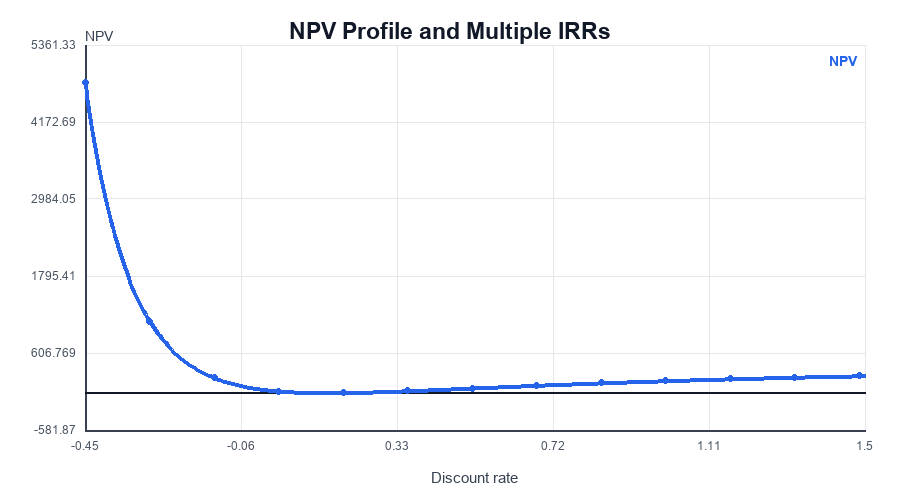


## Chapter Review

- Place every cash flow on a timeline before applying a formula.
- Match the rate frequency with the number of periods.
- Payments at the beginning of a period are more valuable than end-of-period payments.
- Growing annuity formulas use the denominator `r-g`.
- Excel and `numpy-financial` use opposite signs for inflows and outflows.
- NPV directly measures value creation; IRR is a break-even rate.
- Discounted payback is more economically meaningful than ordinary payback, but both ignore later cash flows.
- Multiple sign changes can create multiple IRRs; inspect the NPV profile.
